# ThaiSLM v7 — lab: data → latent space → tagger → segmentation → results → real use

Kernel: conda env `hugging`. This notebook only **reads** what the pipeline produced (`artifacts/reports/*.json`, `models/`,
`cloud_s3/data_prep/`) plus a few small live computations (UMAP, one inference). Nothing here trains or tunes anything.

| section | what you see |
|---|---|
| 1 | data: one extractor (MediaPipe) for everything, daily-conversation word depth, harvested YouTube signers |
| 2 | poses: MediaPipe vs RTMW of the same video, handedness canonicalisation |
| 3 | latent space: UMAP of sign embeddings (zero-shot ASL/CSL prior vs v7), neighbourhood purity, prior bias |
| 4 | frame tagger: P(sign) / P(begin) over real sentences, span head (one-pass) vs exact window scores |
| 5 | segmentation: decoder output vs the reference, transition filter |
| 6 | results: held-out signers, continuous sentences (1× / 1.5× / 2×), data_test |
| 7 | self-made sentence videos (held-out signers, TSL grammar) → full system from the pixels |
| 8 | face channel: blendshapes → question / negation / emotion |
| 9 | production: load the model, inference, sizes, architecture, latency, web API |

In [1]:
import json, sys, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
ROOT = Path.cwd(); sys.path.insert(0, str(ROOT))
plt.rcParams["font.family"] = ["Tahoma", "Leelawadee UI", "DejaVu Sans"]
from modules.utils import ART, MODEL, PREP, read_json
REP = ART / "reports"
def rep(name):
    f = REP / f"{name}.json"
    return read_json(f) if f.exists() else None
cfg = read_json(MODEL / "config.json"); cfg

{'version': 'v7',
 'encoder_run': 'enc-v7-europe-west4',
 'sequence_run': 'seq-v7',
 'tagger_arch': 'gru',
 'extractor': 'MediaPipe Holistic (tasks 1.0.1)',
 'built': '2026-10-03 09:31',
 'concepts': 9923,
 'bank_eval': 14204,
 'bank': 19672,
 'bank_concepts': 9922,
 'conversation_concepts': 322,
 'aligned_sentence_words_added': 650,
 'alignment_score_cut': 0.354}

## 1. Data — one extractor, one schema

In [2]:
clips = pd.read_parquet(PREP / "shards" / "clips.parquet")
prim = clips[clips.view == "primary"]
summary = prim.groupby(["dataset", "extractor"]).agg(clips=("clip_id", "size"), signers=("signer", "nunique"), concepts=("concept", "nunique"),
                                                      hours=("n_frames", lambda f: round(f.sum() / 25 / 3600, 2)))
display(summary)
print("RTMW views of the same videos (extra positives for training, never used at inference):", int((clips.view == "rtmw").sum()))

clips  signers  concepts  hours
dataset      extractor                                 
agent        mp           577       25       472   0.72
th_sl        mp          7716        8      6760   6.60
tsl51        mp           799        1       113   1.07
             mp54        1050       24        51   0.67
tslone       mp75        4147       29       184   2.21
ttrs         mp          5042        9      4685   6.18
youtube_cont mp            16       12         0   0.45

RTMW views of the same videos (extra positives for training, never used at inference): 13573


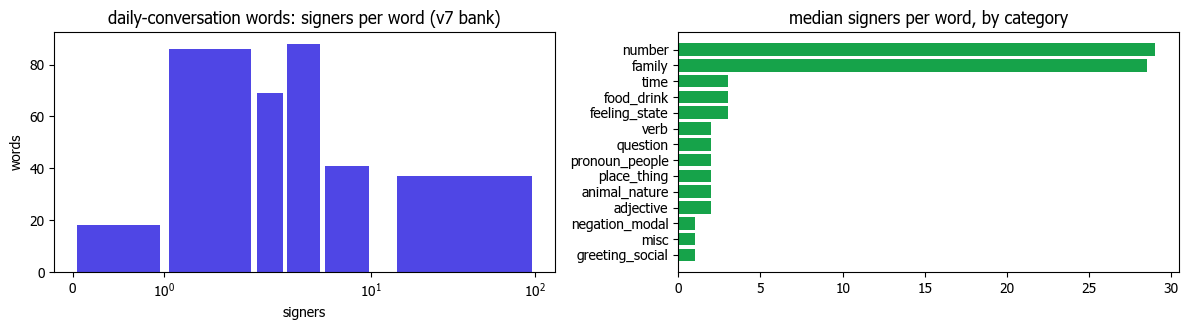

daily words with >= 3 signers: 166 / 339 · not in any source: ['ล่าม', 'ยินดีที่ได้รู้จัก', 'ราตรีสวัสดิ์', 'ไหม', 'หรือเปล่า', 'จะ', 'แล้ว', 'ทำ', 'ตาย', 'นัด', 'ที่ทำงาน', 'รถ', 'ทีวี', 'พัน', 'แดด', 'ทั้งหมด', 'เพราะ', 'กับ']


In [3]:
dd = pd.read_csv(ROOT / "vocab" / "daily_conversation_depth.csv")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
b = [0, 1, 2, 3, 5, 10, 100]
ax[0].hist(dd.signers.clip(upper=99), bins=b, rwidth=0.9, color="#4f46e5"); ax[0].set_xscale("symlog"); ax[0].set_title("daily-conversation words: signers per word (v7 bank)")
ax[0].set_xlabel("signers"); ax[0].set_ylabel("words")
cat = dd.groupby("category").signers.median().sort_values()
ax[1].barh(cat.index, cat.values, color="#16a34a"); ax[1].set_title("median signers per word, by category")
plt.tight_layout(); plt.show()
print("daily words with >= 3 signers:", int((dd.signers >= 3).sum()), "/", len(dd), "· not in any source:", list(dd[dd.signers == 0].word))

status
accepted    577
rejected     85
Name: clips, dtype: int64

reason
no_signing                                 17
many_bursts                                10
no_signer                                   7
span_4.2s                                   7
inconsistent_with_other_channels            6
span_4.6s                                   5
span_4.4s                                   4
span_4.5s                                   4
span_4.0s                                   3
span_5.2s                                   3
span_4.7s                                   3
span_5.0s                                   2
span_4.1s                                   2
span_4.8s                                   2
span_10.3s                                  1
span_6.7s                                   1
span_5.3s                                   1
span_5.4s                                   1
span_9.2s                                   1
duplicate:copy_of_agent:yt:z3MpjTdgGDo      1
span_8.6s                                   1
duplicate:same_video_as_v4_

accepted 577 clips · 472 words · 25 people (channels merged by face)


,title,word,concept,channel,signer,span_s,consistency,role
189,ทักทาย-ภาษามือ,ทักทาย,ทักทาย,thaisign oo,yt_person_035,1.88,NaN,train
491,หุ่นไล่กา,หุ่นไล่กา,หุ่นไล่กา,NaN,yt_person_021,1.32,NaN,train
308,31 มรดก,มรดก,มรดก,NaN,yt_person_021,3.12,NaN,train
561,ภาษามือ[เริ่ม],เริ่ม,เริ่ม,poopaye patato,yt_person_004,1.80,NaN,test
390,ภาษามือคำว่า “วิทยุ”,วิทยุ,วิทยุ,NaN,yt_person_017,2.16,NaN,train
629,ภาษามือ[โบสถ์],โบสถ์,โบสถ์,NaN,yt_person_004,2.24,NaN,test
108,#16 ภาษามือ คำศัพท์ จับ,จับ,จับ,NaN,yt_person_021,2.52,0.985,train
246,ภาษามือ ‘ปลา’,ปลา,ปลา,risa. jittadoo1809,yt_person_029,1.88,1.000,train


Signer identities of the harvested channels (one row per person; last rows = data_test people, checked for leakage)

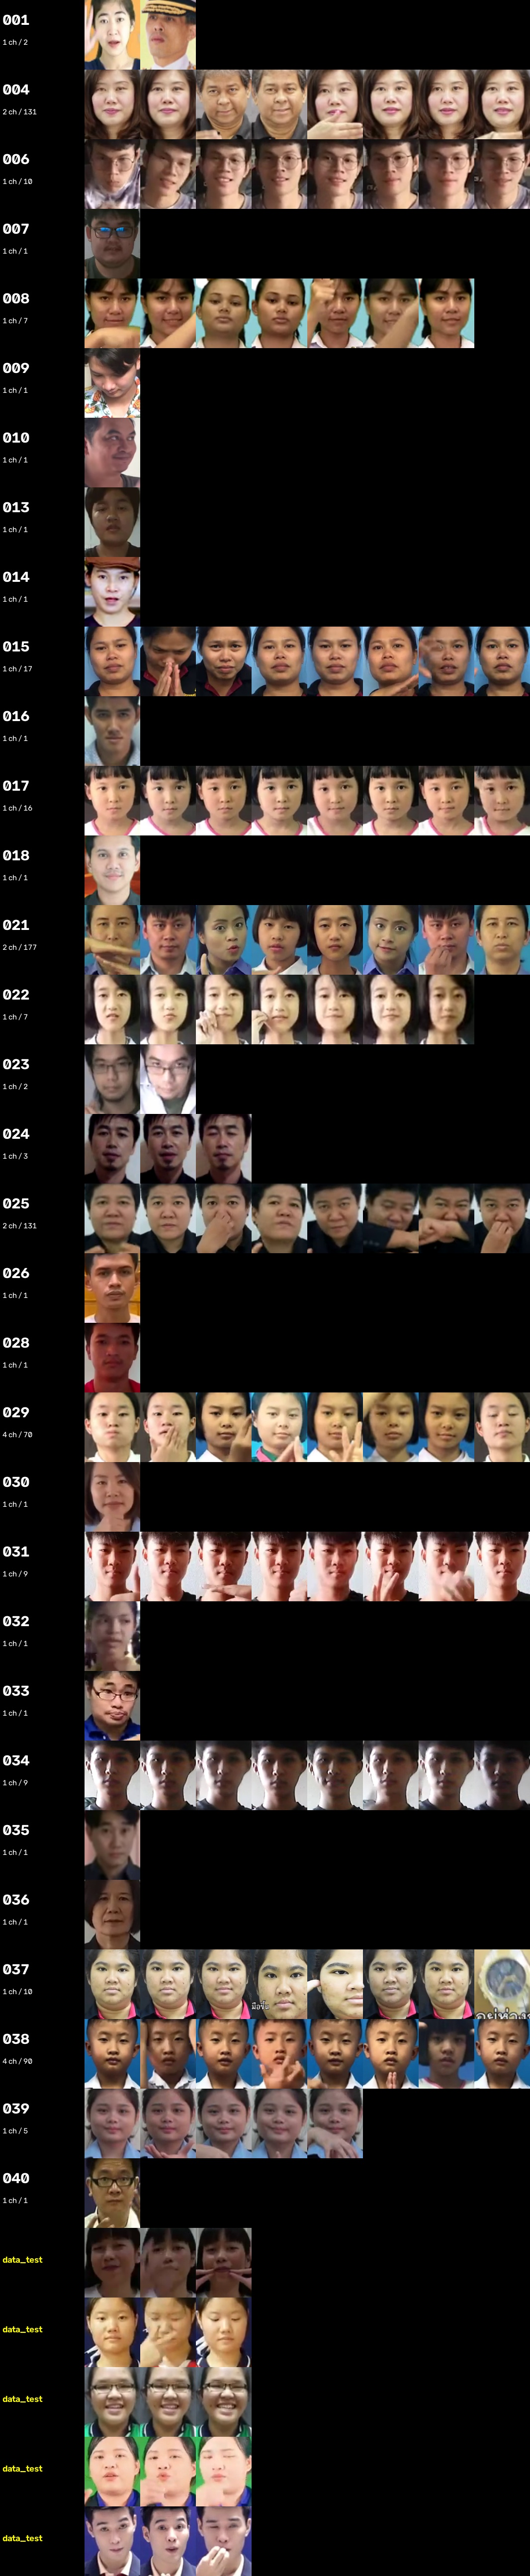

In [4]:
it = Path(PREP).parent / "agent_data" / "youtube_words" / "items.csv"
if it.exists():
    ag = pd.read_csv(it)
    display(ag.groupby(["status"]).size().rename("clips"))
    display(ag[ag.status == "rejected"].reason.str.split("(").str[0].value_counts().rename("rejected because"))
    acc = ag[ag.status == "accepted"]
    print(f"accepted {len(acc)} clips · {acc.concept.nunique()} words · {acc.signer.nunique()} people (channels merged by face)")
    display(acc.sample(min(8, len(acc)), random_state=0)[["title", "word", "concept", "channel", "signer", "span_s", "consistency", "role"]])
    q = it.parent / "qc" / "agent_signers.jpg"
    if q.exists():
        display(Markdown("Signer identities of the harvested channels (one row per person; last rows = data_test people, checked for leakage)"))
        display(Image(str(q), width=900))

## 2. Poses — the extractor gap, and why v7 removes it

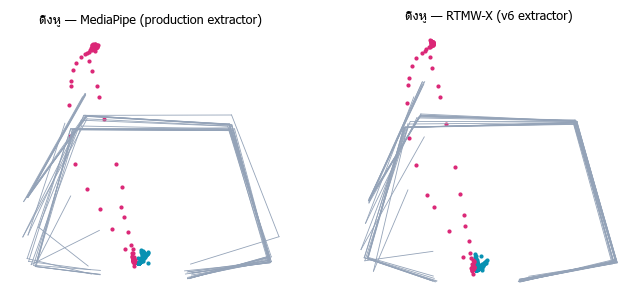

same video, MediaPipe vs RTMW → cosine of the two embeddings: {'n': (800, 800), 'same_clip': (0.815, 0.848), 'random_clip': (0.181, 0.02)} (zero-shot, v7)
clips mirrored to right-hand-dominant: 177 of 19347


In [5]:
from modules.schema import load, iso
def skel(ax, kp, sc, title):
    p = kp.copy()
    for a, b in [(5, 6), (5, 7), (7, 9), (6, 8), (8, 10)]:
        ok = (sc[:, a] > 0.3) & (sc[:, b] > 0.3)
        for t in np.flatnonzero(ok)[::6]:
            ax.plot(p[t, [a, b], 0], -p[t, [a, b], 1], color="#94a3b8", lw=0.6)
    for sl, col in ((slice(91, 112), "#0891b2"), (slice(112, 133), "#db2777")):
        m = sc[:, sl].mean(1) > 0.3
        ax.scatter(p[m, sl][:, :, 0].mean(1), -p[m, sl][:, :, 1].mean(1), s=4, color=col)
    ax.set_title(title, fontsize=9); ax.set_aspect("equal"); ax.axis("off")
cid = prim[(prim.dataset == "ttrs") & prim.aux_clip.notna()].iloc[0]
store = np.load(PREP / "shards" / "pose_store.npz", allow_pickle=True)
from modules.encoder import PoseStore
S = PoseStore(PREP / "shards" / "pose_store.npz")
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for k, (c, name) in enumerate(((cid.clip_id, "MediaPipe (production extractor)"), (cid.aux_clip, "RTMW-X (v6 extractor)"))):
    kp, sc, hw = S.get(S.row[c])
    skel(ax[k], iso(kp, hw), sc, f"{cid.concept} — {name}")
plt.show()
iso_ = rep("isolated")
if iso_:
    pc = [r for r in iso_["table"] if r["protocol"] == "extractor_pair_cos"]
    print("same video, MediaPipe vs RTMW → cosine of the two embeddings:", {r["metric"]: (round(r["zero_shot"], 3), round(r["v7"], 3)) for r in pc}, "(zero-shot, v7)")
print("clips mirrored to right-hand-dominant:", int(prim.mirrored.sum()), "of", len(prim))

## 3. Latent space — does the model learn Thai signs, or lean on the ASL/CSL prior?

C:\Users\BM MONEY\AppData\Local\Temp\ipykernel_25832\2673610565.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sel = idx[idx.concept.isin(top)].groupby("concept", group_keys=False).apply(lambda g: g.sample(min(len(g), 60), random_state=0))


C:\Users\BM MONEY\miniconda3\envs\hugging\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\BM MONEY\miniconda3\envs\hugging\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


C:\Users\BM MONEY\miniconda3\envs\hugging\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


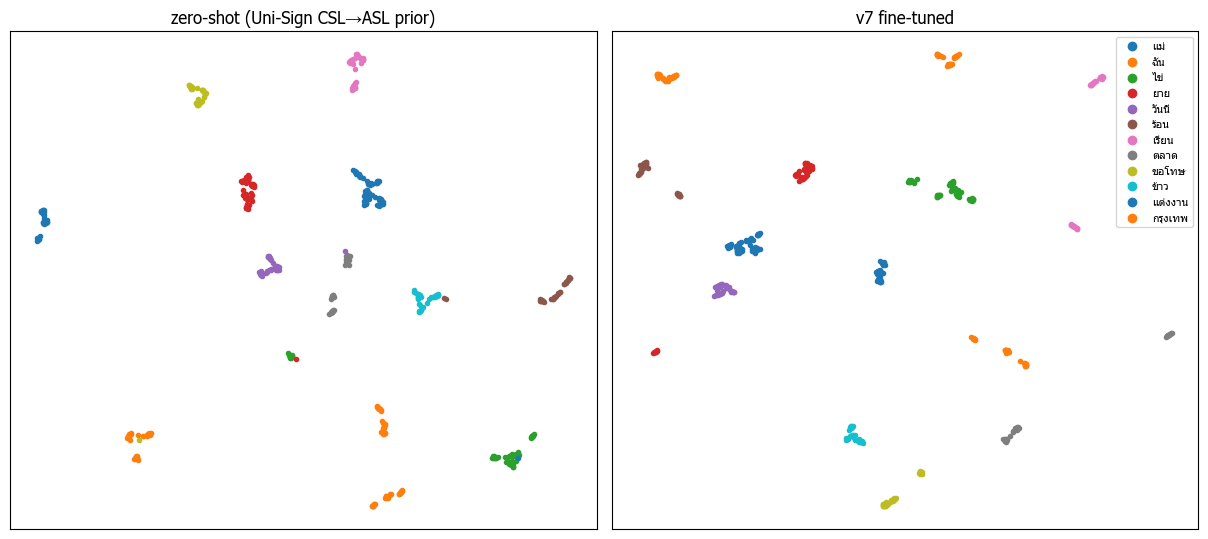

,knn5_same_concept,knn5_same_signer,knn5_same_dataset
zero_shot,0.322,0.255,0.732
v7,0.364,0.231,0.703
v6,0.362,0.227,0.689


**Prior bias** (of v7's errors on held-out signers, how many are the zero-shot ASL/CSL model's *same* wrong answer):

inherited_confusion_rate                 0.408
zero_shot_errors_fixed                   0.083
new_errors_introduced                    0.086
cka_zero_shot_vs_v7                      0.658
v6_inherited_confusion_rate_same_data    0.368
dtype: float64

In [6]:
run = ART / "runs" / cfg["encoder_run"]
idx = pd.read_parquet(run / "emb_index.parquet")
Z1, Z0 = np.load(run / "emb.npy").astype(np.float32), np.load(run / "emb_zero_shot.npy").astype(np.float32)
conv = read_json(MODEL / "vocab_conversation.json")["concepts"]
top = idx[idx.concept.isin(conv) & (idx.kind == "isolated")].concept.value_counts()
top = [c for c in top.index if idx[idx.concept == c].signer.nunique() >= 4][:12]
sel = idx[idx.concept.isin(top)].groupby("concept", group_keys=False).apply(lambda g: g.sample(min(len(g), 60), random_state=0))
import umap
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
for k, (Z, name) in enumerate(((Z0, "zero-shot (Uni-Sign CSL→ASL prior)"), (Z1, "v7 fine-tuned"))):
    U = umap.UMAP(n_neighbors=15, min_dist=0.2, metric="cosine", random_state=0).fit_transform(Z[sel.index.values])
    for c in top:
        m = (sel.concept == c).values
        ax[k].scatter(U[m, 0], U[m, 1], s=9, label=c)
    ax[k].set_title(name); ax[k].set_xticks([]); ax[k].set_yticks([])
ax[1].legend(fontsize=8, markerscale=2, bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()
if iso_:
    display(pd.DataFrame(iso_["latent"]).T.round(3))
    display(Markdown("**Prior bias** (of v7's errors on held-out signers, how many are the zero-shot ASL/CSL model's *same* wrong answer):"))
    display(pd.Series(iso_["prior_bias"]).round(3))

## 4. Frame tagger and the one-pass span head

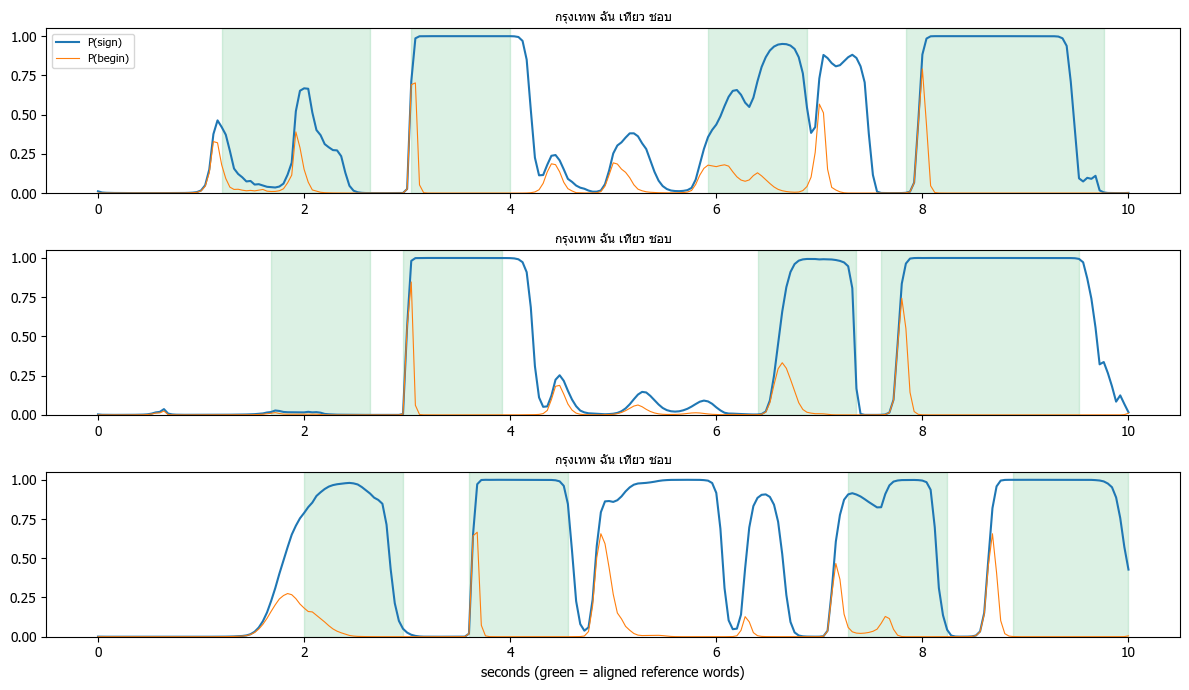

one-pass (span head) vs per-window teacher on the TSL51 test templates:


,one-pass span head (deployed),teacher windows (slow)
real_test_x1.0,0.598,0.58
real_test_x1.5,0.584,NaN
real_test_x2.0,0.531,NaN


In [7]:
import pickle
seq = ART / "runs" / cfg["sequence_run"]
D = pickle.load(open(seq / "seq_tables.pkl", "rb"))
items = [it for it in D["items"] if it["kind"] == "real" and it["split"] == "test" and it["speed"] == 1.0]
from modules.segment import gt_segments
fig, axs = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
for ax, it in zip(axs, items[:3]):
    p = it["prob"].astype(np.float32); t = np.arange(len(p)) / 25
    ax.plot(t, p[:, 1] + p[:, 2], label="P(sign)"); ax.plot(t, p[:, 1], label="P(begin)", lw=0.8)
    for g0, g1 in gt_segments(it["y"]):
        ax.axvspan(g0 / 25, g1 / 25, color="#16a34a", alpha=0.15)
    ax.set_title(" ".join(it["glosses"]), fontsize=9); ax.set_ylim(0, 1.05)
axs[0].legend(fontsize=8); axs[-1].set_xlabel("seconds (green = aligned reference words)")
plt.tight_layout(); plt.show()
sp = rep("spotting")
if sp:
    c = sp["conversation"]
    print("one-pass (span head) vs per-window teacher on the TSL51 test templates:")
    display(pd.DataFrame({"one-pass span head (deployed)": {k: c[k]["word_recall_top1"] for k in c if k.startswith("real_test")},
                          "teacher windows (slow)": {k: v["word_recall_top1"] for k, v in c["teacher_windows_on_test"].items() if k.startswith("real_test")}}).round(3))

## 5. Segmentation — decoder vs reference, and the transition filter

**พ่อดื่มน้ำ** (data_test) — grey = transition (not used in the sentence)

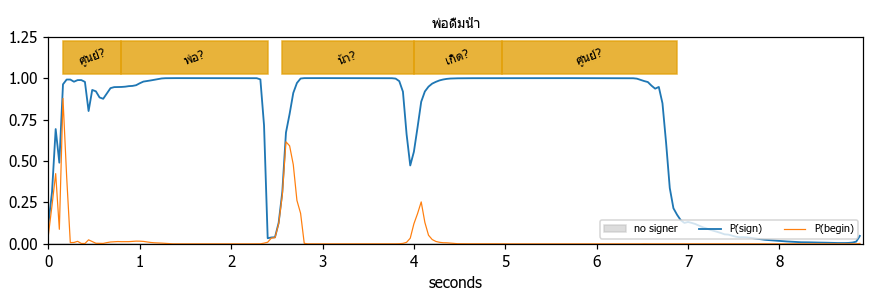

**ฉันรักเพื่อน** (data_test) — grey = transition (not used in the sentence)

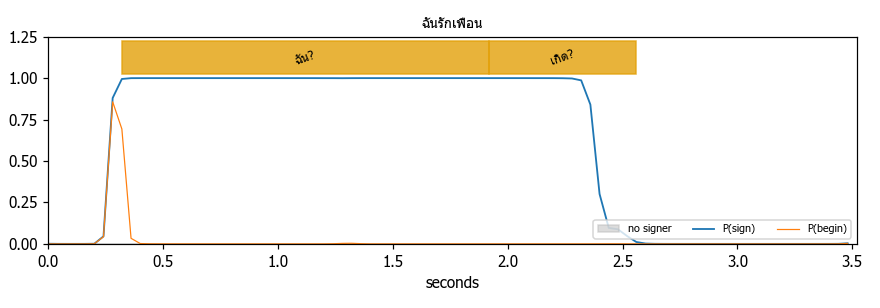

In [8]:
from modules.pipeline import timeline
inf = rep("infer_final")
for stem in ["พ่อดื่มน้ำ", "ฉันรักเพื่อน"]:
    f = ROOT / "result_reporting" / "inference" / "conversation" / stem / "timeline.png"
    if f.exists():
        display(Markdown(f"**{stem}** (data_test) — grey = transition (not used in the sentence)")); display(Image(str(f)))

## 6. Results

In [9]:
if iso_:
    rows = {k: {n: v.get("R1") for n, v in d.items()} for k, d in iso_["comparison"].items()}
    display(Markdown("**Isolated signs, held-out signers (R@1, same queries and same bank for every encoder)**"))
    display(pd.DataFrame(rows).T.round(3))
    display(Markdown("**Recall by bank depth (signers per word)**")); display(pd.DataFrame(iso_["recall_by_depth"]).round(3))
if sp:
    for vocab in ("conversation", "full"):
        r = sp[vocab]
        t = pd.DataFrame({k: {m: r[k][m] for m in ("seg_f1", "exact_count_rate", "word_recall_top1", "word_precision_top1", "WER")} for k in r if k.startswith(("real_test", "synth_test"))}).T
        display(Markdown(f"**Continuous signing — {vocab} vocabulary (TSL51 test templates never used for any decision)**")); display(t.round(3))

**Isolated signs, held-out signers (R@1, same queries and same bank for every encoder)**

,zero_shot,v7,v6
TTRS_test,0.131,0.202,0.167
"TTRS_test · daily words, conversation vocab",0.222,0.333,0.222
THSL_test,0.073,0.122,0.091
"THSL_test · daily words, conversation vocab",0.333,0.444,0.333
ONE_test,0.784,0.857,0.845
"ONE_test · daily words, conversation vocab",0.906,0.917,0.917
"AGENT_test (YouTube, new channels)",0.310,0.352,0.310
"AGENT_test (YouTube, new channels) · daily words, conversation vocab",0.528,0.611,0.583
"T51U (TSL51 researcher, video)",0.397,0.389,0.275
"T51U (TSL51 researcher, video) · daily words, conversation vocab",0.698,0.683,0.582


**Recall by bank depth (signers per word)**

,depth,n,R1
0,0,1081,0.001
1,1,320,0.147
2,2,92,0.185
3,3-4,239,0.368
4,5-9,269,0.405
5,10+,915,0.838


**Continuous signing — conversation vocabulary (TSL51 test templates never used for any decision)**

,seg_f1,exact_count_rate,word_recall_top1,word_precision_top1,WER
real_test_x1.0,0.866,0.659,0.598,0.556,0.446
real_test_x1.5,0.838,0.627,0.584,0.631,0.391
real_test_x2.0,0.779,0.508,0.531,0.613,0.415
synth_test,0.918,0.508,0.592,0.113,1.036


**Continuous signing — full vocabulary (TSL51 test templates never used for any decision)**

,seg_f1,exact_count_rate,word_recall_top1,word_precision_top1,WER
real_test_x1.0,0.848,0.579,0.456,0.434,0.618
real_test_x1.5,0.824,0.595,0.433,0.479,0.565
real_test_x2.0,0.733,0.405,0.396,0.488,0.581
synth_test,0.939,0.650,0.430,0.390,0.690


In [10]:
if inf:
    for vocab, res in inf["results"].items():
        display(Markdown(f"**data_test — {vocab} vocabulary**: {json.dumps(res['summary'], ensure_ascii=False)}"))
        display(pd.DataFrame({k: dict(reference=" ".join(v["ref"]), top1=" ".join(v["top1"]), sentence=v["sentence"] or f"(withheld) {v['tentative'] or ''}",
                                      R1=v["recall_top1"], R5=v["recall_top5"]) for k, v in res["videos"].items()}).T)

**data_test — conversation vocabulary**: {"videos": 5, "ref_words": 22, "segments": 23, "recall_top1": 0.4090909090909091, "recall_top5": 0.7272727272727273, "ref_words_in_sentence": 0.22727272727272727, "words_in_sentence": 11, "words_in_sentence_correct": 5, "accepted": 4, "accepted_correct": 4, "count_abs_err": 1.0, "mean_WER_top1": 0.8742857142857142, "mean_WER_sentence": 0.8642857142857142, "mean_latency_ms": 4684.4}

,reference,top1,sentence,R1,R5
test1,สวัสดี สบายดี ชอบ โกรธ แมว แฟน ปรบมือ,สวัสดี สบายดี ฉัน ชอบ หก แมว นั่ง แมว,สวัสดี สบายดี ฉันชอบแมวนั่ง,0.571429,0.857143
ฉันปลอบเพื่อนร้องไห้,ฉัน ปลอบใจ เพื่อน ร้องไห้,เพื่อน ดู ข้าว เกิด,เพื่อนดู[?][?],0.25,0.75
ฉันรักเพื่อน,ฉัน รัก เพื่อน,ฉัน เกิด,(withheld) ฉันกิน,0.333333,0.333333
พ่อดื่มน้ำ,พ่อ ดื่ม น้ำ,ศูนย์ พ่อ น้า เกิด ศูนย์,(withheld) บ้าน,0.333333,1.0
ไปทานข้าวด้วยกันมั้ย,ไป กิน ข้าว ด้วยกัน ไหม,คุณ ฉัน ข้าว ไป,(withheld),0.4,0.6


**data_test — full vocabulary**: {"videos": 5, "ref_words": 22, "segments": 22, "recall_top1": 0.45454545454545453, "recall_top5": 0.5909090909090909, "ref_words_in_sentence": 0.18181818181818182, "words_in_sentence": 8, "words_in_sentence_correct": 4, "accepted": 1, "accepted_correct": 1, "count_abs_err": 1.2, "mean_WER_top1": 0.8361904761904763, "mean_WER_sentence": 0.8547619047619047, "mean_latency_ms": 4227.14}

,reference,top1,sentence,R1,R5
test1,สวัสดี สบายดี ชอบ โกรธ แมว แฟน ปรบมือ,สวัสดี ไป ฉัน ชอบ โลก แมว เหมือนกัน โฆษณา,(withheld),0.428571,0.571429
ฉันปลอบเพื่อนร้องไห้,ฉัน ปลอบใจ เพื่อน ร้องไห้,เพื่อน ดู เกิด สงสาร,เพื่อนดู[?][?],0.25,0.5
ฉันรักเพื่อน,ฉัน รัก เพื่อน,ฉัน,(withheld) ฉัน,0.333333,0.333333
พ่อดื่มน้ำ,พ่อ ดื่ม น้ำ,โอ พ่อ น้ำ ดื่ม ศูนย์,(withheld),1.0,1.0
ไปทานข้าวด้วยกันมั้ย,ไป กิน ข้าว ด้วยกัน ไหม,ฉัน เกิด ข้าว ไป,(withheld) ฉันไป,0.4,0.6


## 7. Self-made sentence videos (TSL grammar) → the full system from the pixels

Sentences are written in **TSL word order** (topic/object first, verb late, question last — the pattern of TSL51 and the
interpreters' videos), e.g. `พ่อ น้ำ ดื่ม` → *พ่อดื่มน้ำ*, `วันนี้ ฉัน โรงเรียน ไป` → *วันนี้ฉันไปโรงเรียน*. Each word is a real video clip of a
**held-out signer** (test roles: never in training, and this evaluation uses the training-signer bank only), cut to its signing span
and joined with a short cross-fade (the hand transition between signs), at natural (1.3×) and fast phone pace (1.8×). The system
then runs from the pixels: MediaPipe → schema → tagger → spotting → sentence.

In [11]:
st = rep("selftest")
if st:
    for vocab in ("conversation",):
        display(Markdown(f"**{vocab}**: {json.dumps(st[vocab]['summary'], ensure_ascii=False)}"))
        display(pd.DataFrame({k: s for k, s in st[vocab]["by_speed"].items()}).T[["recall_top1", "recall_top5", "ref_words_in_sentence", "words_in_sentence_correct", "words_in_sentence", "count_abs_err"]])
        v = st[vocab]["videos"]
        display(pd.DataFrame({k: dict(TSL_order=" ".join(x["ref"]), meaning=x["thai_reference"], speed=x["speed"], predicted=" ".join(x["top1"]),
                                      sentence=x["sentence"] or f"(withheld) {x['tentative'] or ''}") for k, x in list(v.items())[:30]}).T)

**conversation**: {"videos": 32, "ref_words": 88, "segments": 91, "recall_top1": 0.5909090909090909, "recall_top5": 0.8522727272727273, "ref_words_in_sentence": 0.36363636363636365, "words_in_sentence": 46, "words_in_sentence_correct": 32, "accepted": 12, "accepted_correct": 12, "count_abs_err": 0.28125, "mean_WER_top1": 0.4895833333333333, "mean_WER_sentence": 0.6223958333333333, "mean_latency_ms": 2038.3656250000004}

,recall_top1,recall_top5,ref_words_in_sentence,words_in_sentence_correct,words_in_sentence,count_abs_err
1.3,0.613636,0.863636,0.340909,15.0,22.0,0.3750
1.8,0.568182,0.840909,0.386364,17.0,24.0,0.1875


,TSL_order,meaning,speed,predicted,sentence
S_51_user__วันนี้_น้อง_ร้อน__x1.3.mp4,วันนี้ น้อง ร้อน,วันนี้น้องร้อน,1.3,วันนี้ น้อง ดีใจ,(withheld)
S_51_user__วันนี้_น้อง_ร้อน__x1.8.mp4,วันนี้ น้อง ร้อน,วันนี้น้องร้อน,1.8,วันนี้ น้อง ดีใจ,(withheld) วันนี้ [?] [?]
S_51_user__ยาย_ง่วง__x1.3.mp4,ยาย ง่วง,ยายง่วง,1.3,ย่า บ้าน,(withheld) ยาย [?]
S_51_user__ยาย_ง่วง__x1.8.mp4,ยาย ง่วง,ยายง่วง,1.8,ย่า บ้าน,(withheld) ยาย [?]
S_51_user__พรุ่งนี้_พี่_บ้าน_เที่ยว__x1.3.mp4,พรุ่งนี้ พี่ บ้าน เที่ยว,พรุ่งนี้พี่เที่ยวบ้าน,1.3,พรุ่งนี้ พี่ บ้าน ที่ไหน,พี่อยู่บ้านที่ไหน
S_51_user__พรุ่งนี้_พี่_บ้าน_เที่ยว__x1.8.mp4,พรุ่งนี้ พี่ บ้าน เที่ยว,พรุ่งนี้พี่เที่ยวบ้าน,1.8,พี่ บ้าน ที่ไหน,(withheld) พี่อยู่บ้าน
S_51_user__พี่_เหงา__x1.3.mp4,พี่ เหงา,พี่เหงา,1.3,พี่ เหงา,(withheld) พี่ [?]
S_51_user__พี่_เหงา__x1.8.mp4,พี่ เหงา,พี่เหงา,1.8,พี่ เหงา,(withheld) พี่ [?]
S_51_user__น้อง_ตลาด_ชอบ__x1.3.mp4,น้อง ตลาด ชอบ,น้องชอบตลาด,1.3,น้อง ขนมปัง แม่ ชอบ,ชอบ
S_51_user__น้อง_ตลาด_ชอบ__x1.8.mp4,น้อง ตลาด ชอบ,น้องชอบตลาด,1.8,น้อง รถไฟ ชอบ,ขนมปังชอบ


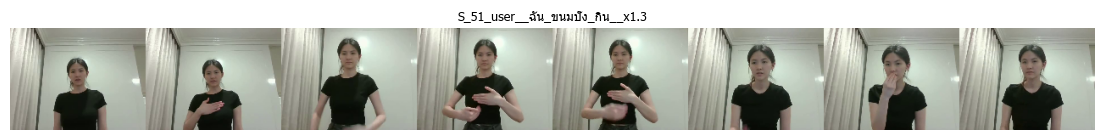

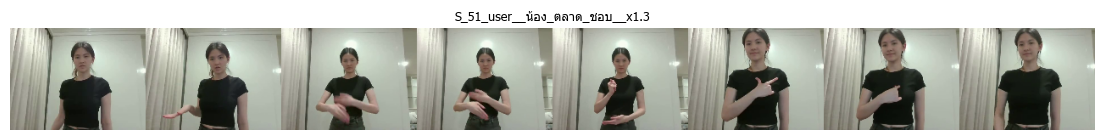

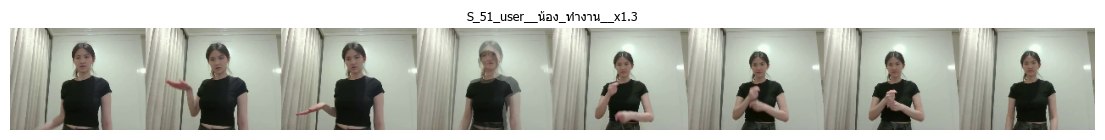

In [12]:
import cv2
d = ROOT / "cache" / "selftest"
vids = sorted(d.glob("*x1.3.mp4"))[:3]
for v in vids:
    cap = cv2.VideoCapture(str(v)); n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); fr = []
    for i in np.linspace(0, n - 1, 8).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i)); ok, f = cap.read()
        if ok: fr.append(cv2.resize(f, (160, int(160 * f.shape[0] / f.shape[1]))))
    cap.release()
    if fr:
        plt.figure(figsize=(14, 2.2)); plt.imshow(cv2.cvtColor(np.concatenate(fr, 1), cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.title(v.stem, fontsize=9); plt.show()

## 8. Face channel — blendshapes → question / negation / emotion

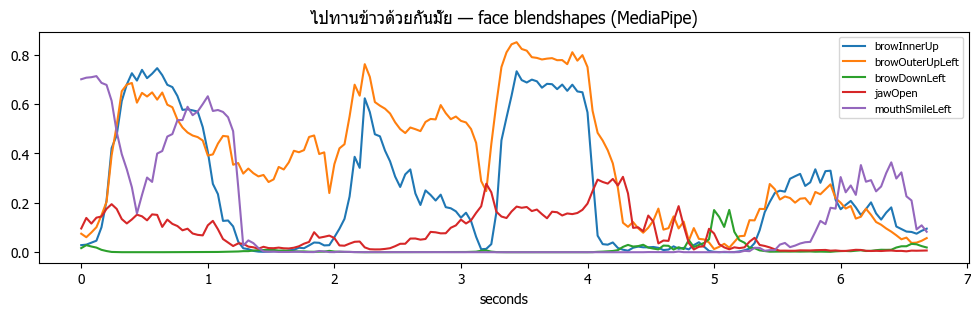

{
 "face_frames": 1.0,
 "question_yesno": false,
 "question_wh": false,
 "negation": false,
 "affirmation": false,
 "emotion": "neutral",
 "emotion_th": "เป็นกลาง",
 "emotion_scores": {
  "happy": 0.436,
  "sad": 0.0,
  "angry": 0.054,
  "surprise": 0.128,
  "fear": 0.01,
  "disgust": 0.0
 },
 "intensity": 0.0,
 "cues": {
  "brow_raise_tail": -0.758,
  "brow_raise_peak": 0.325,
  "brow_furrow": 1.237,
  "head_forward_tail": 0.018,
  "head_shake_cycles": 0,
  "head_nod_cycles": 1,
  "mouth_open_frac": 0.0,
  "cheek_puff": 0.0,
  "duration_s": 6.68
 }
}


In [13]:
from modules.mediapipe_pose import load_raw, BLENDSHAPES
from modules.face import analyse
f = ROOT / "cache" / "data_test_mp" / "ไปทานข้าวด้วยกันมั้ย.npz"
if f.exists():
    raw = load_raw(f); B = {n: i for i, n in enumerate(BLENDSHAPES)}
    t = raw["t"]
    plt.figure(figsize=(12, 3))
    for n in ("browInnerUp", "browOuterUpLeft", "browDownLeft", "jawOpen", "mouthSmileLeft"):
        plt.plot(t, raw["bs"][:, B[n]], label=n)
    plt.legend(fontsize=8); plt.xlabel("seconds"); plt.title("ไปทานข้าวด้วยกันมั้ย — face blendshapes (MediaPipe)"); plt.show()
    print(json.dumps({k: v for k, v in analyse(raw).items() if k != "per_segment"}, ensure_ascii=False, indent=1))

## 9. Production — load, infer, inspect

In [14]:
from modules.pipeline import SignPipeline
pipe = SignPipeline(backend="onnx", device="cpu", vocab="conversation", use_llm=False)   # ONNX Runtime only — what the web API runs
r = pipe.run(ROOT / "data_test" / "พ่อดื่มน้ำ.mp4")                                         # MediaPipe → … → sentence
print("evidence:", r["fusion"]["evidence_gloss"]); print("sentence:", r["sentence"] or "(withheld)"); print("timings (ms):", r["timings_ms"])

evidence: ศูนย์? | พ่อ? | น้า? | เกิด? | ศูนย์?
sentence: (withheld)
timings (ms): {'schema_ms': 51.5, 'tagger_ms': 505.2, 'spotting_ms': 240.6, 'n_windows': 423, 'tempo_factor': 1.0, 'face_ms': 4.2, 'language_ms': 3.1, 'mediapipe_ms': 9439.5}


In [15]:
# the same call from landmarks (what the browser sends): frames = [{t, pose[33×4], lh[21×3], rh[21×3], face[68×2], bs[52]}, …]
from modules.mediapipe_pose import extract
raw = extract(ROOT / "data_test" / "ฉันรักเพื่อน.mp4")
t = time.perf_counter(); r = pipe.run_landmarks(raw); print(f"{(time.perf_counter()-t)*1000:.0f} ms for {r['duration_s']} s of signing →", r["fusion"]["evidence_gloss"])

311 ms for 3.52 s of signing → ฉัน? | เกิด?


In [16]:
import onnx, torch
sizes = {p.name: f"{p.stat().st_size/1e6:.1f} MB" for p in sorted(list(MODEL.glob('*.pt')) + list(MODEL.glob('*.npz')) + list((MODEL / 'onnx').glob('*.onnx')) + list((MODEL / 'mediapipe').glob('*')))}
display(pd.Series(sizes, name="size"))
from modules.encoder import load_encoder
enc = load_encoder(MODEL, MODEL / "encoder.pt", device="cpu")
n_all = sum(p.numel() for p in enc.parameters()); n_gcn = sum(p.numel() for p in enc.pose.parameters()); n_head = sum(p.numel() for p in enc.head.parameters())
print(f"sign encoder: {n_all/1e6:.1f} M parameters (ST-GCN {n_gcn/1e6:.1f} M · mT5 encoder {(n_all-n_gcn-n_head)/1e6:.1f} M · head {n_head/1e6:.2f} M)")
from modules.sequence import Tagger
tg = Tagger(); print(f"tagger (BiGRU): {sum(p.numel() for p in tg.parameters())/1e6:.2f} M parameters")
sh = np.load(MODEL / "span_head.npz"); print("span head:", {k: v.shape for k, v in sh.items()})
m = onnx.load(str(MODEL / "onnx" / "encoder.onnx"), load_external_data=False)
print("encoder.onnx inputs:", [(i.name, [d.dim_param or d.dim_value for d in i.type.tensor_type.shape.dim]) for i in m.graph.input])
print("encoder.onnx outputs:", [(o.name, [d.dim_param or d.dim_value for d in o.type.tensor_type.shape.dim]) for o in m.graph.output])
print(enc.head); print(tg)

bank.npz                     41.5 MB
encoder.pt                  187.0 MB
face_template.npz             0.0 MB
holistic_landmarker.task     13.7 MB
encoder.onnx                367.9 MB
tagger.onnx                   5.1 MB
span_head.npz                15.8 MB
tagger.pt                     5.1 MB
Name: size, dtype: object

sign encoder: 91.9 M parameters (ST-GCN 5.3 M · mT5 encoder 85.0 M · head 1.58 M)
tagger (BiGRU): 1.26 M parameters
span head: {'q': (768,), 'ln_g': (3073,), 'ln_b': (3073,), 'W1': (3073, 1024), 'b1': (1024,), 'W2': (1024, 768), 'b2': (768,)}


encoder.onnx inputs: [('body', ['B', 'T', 9, 3]), ('left', ['B', 'T', 21, 3]), ('right', ['B', 'T', 21, 3]), ('face_all', ['B', 'T', 18, 3]), ('mask', ['B', 'T'])]
encoder.onnx outputs: [('embedding', ['B', 'Divembedding_dim_1']), ('frames', ['B', 'T', 768])]
Sequential(
  (0): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (1): Linear(in_features=768, out_features=1024, bias=True)
  (2): GELU(approximate='none')
  (3): Dropout(p=0.1, inplace=False)
  (4): Linear(in_features=1024, out_features=768, bias=True)
)
Tagger(
  (inp): Sequential(
    (0): LayerNorm((781,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=781, out_features=192, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
  )
  (gru): GRU(192, 192, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (out): Linear(in_features=384, out_features=3, bias=True)
)


In [17]:
# latency on this machine (CPU, ONNX Runtime): one-pass spotting for utterances of different lengths
from modules.mediapipe_pose import load_raw
raw = load_raw(ROOT / "cache" / "data_test_mp" / "พ่อดื่มน้ำ.npz")
for n in (60, 125, 250):
    sub = {k: (v[:n] if np.ndim(v) > 0 and len(v) == len(raw["t"]) else v) for k, v in raw.items()}
    t = time.perf_counter(); pipe.run_landmarks(sub); print(f"{n/25:.1f} s of video → {(time.perf_counter()-t)*1000:.0f} ms")

2.4 s of video → 275 ms


5.0 s of video → 437 ms


10.0 s of video → 774 ms


### Web API (docker compose up --build → http://localhost:8080)

```python
import requests
r = requests.post("http://localhost:8080/api/v1/translate/video", files={"file": open("data_test/พ่อดื่มน้ำ.mp4", "rb")}, params={"vocab": "conversation"})
r.json()["sentence"], r.json()["segments"]
# browser path: POST /api/v1/translate {frames: [...MediaPipe landmarks...], width, height, vocab, llm, speak}
# speech:      POST /tts/v1/speak {text, emotion} → audio/wav
```